In [0]:
df = spark.read.format("parquet").load(
    "s3://gold-data-s3/gold-data/ml_dataset/fact_ml_dataset/"
)

In [0]:
df = spark.read.parquet(
    "s3a://gold-data-s3/gold-data/ml_dataset/fact_ml_dataset/"
)

In [0]:
df.show(10)

+-------+----------+---------------+--------+---------+-----------+-------+-------+----------+------------------+------------------+------------------+------------+-------------------+----------+----------------+---------------+------------------+-------------------+------------------+-------------------+----+-----+---+-------+----+-----------+----------+----------+----------------+---------+----------+---------------+----------+
|city_id| city_name|       district|state_id|region_id|region_name|    lat|    lng|      date|avg_temperature_2m|max_temperature_2m|min_temperature_2m|avg_humidity|daily_precipitation|daily_rain|avg_pressure_msl|avg_cloud_cover|avg_wind_speed_10m|avg_wind_speed_100m|max_wind_speed_10m|max_wind_speed_100m|year|month|day|quarter|week|day_of_week|is_weekend|heavy_rain|high_temperature|high_wind|high_cloud|extreme_weather|state_name|
+-------+----------+---------------+--------+---------+-----------+-------+-------+----------+------------------+------------------+

In [0]:
df = spark.read.parquet(
    "s3://gold-data-s3/gold-data/ml_dataset/fact_ml_dataset/state_name=Andaman & Nicobar/"
)

In [0]:
df = spark.read.parquet("s3://gold-data-s3/gold-data/ml_dataset/fact_ml_dataset/state_name=Andaman & Nicobar/")

In [0]:
df.show(15)

+-------+----------+---------------+--------+---------+-----------+-------+-------+----------+------------------+------------------+------------------+------------+-------------------+----------+----------------+---------------+------------------+-------------------+------------------+-------------------+----+-----+---+-------+----+-----------+----------+----------+----------------+---------+----------+---------------+
|city_id| city_name|       district|state_id|region_id|region_name|    lat|    lng|      date|avg_temperature_2m|max_temperature_2m|min_temperature_2m|avg_humidity|daily_precipitation|daily_rain|avg_pressure_msl|avg_cloud_cover|avg_wind_speed_10m|avg_wind_speed_100m|max_wind_speed_10m|max_wind_speed_100m|year|month|day|quarter|week|day_of_week|is_weekend|heavy_rain|high_temperature|high_wind|high_cloud|extreme_weather|
+-------+----------+---------------+--------+---------+-----------+-------+-------+----------+------------------+------------------+------------------+---

In [0]:
from pyspark.sql.functions import when

df = df.withColumn(
    "season",
    when(df.month.isin([6,7,8,9]), "Kharif")
    .when(df.month.isin([10,11,12,1,2]), "Rabi")
    .otherwise("Zaid")
)

In [0]:
from pyspark.sql.functions import avg, sum, stddev

season_df = df.groupBy(
    "city_id",
    "city_name",
    "district",
    "season"
).agg(

    avg("avg_temperature_2m").alias("avg_temp"),

    avg("max_temperature_2m").alias("max_temp"),

    avg("min_temperature_2m").alias("min_temp"),

    sum("daily_precipitation").alias("season_rain"),

    avg("avg_humidity").alias("humidity"),

    avg("avg_cloud_cover").alias("cloud"),

    avg("avg_wind_speed_10m").alias("wind"),

    sum("extreme_weather").alias("extreme_days"),

    stddev("avg_temperature_2m").alias("temp_std"),

    stddev("daily_precipitation").alias("rain_std")
)

In [0]:
from pyspark.sql.functions import col

season_df = season_df.withColumn(
    "temp_range",
    col("max_temp") - col("min_temp")
)

season_df = season_df.fillna(0)

In [0]:
season_df = season_df.withColumn(
    "weather_stability",
    1/(col("temp_std")+col("rain_std")+1)
)

# Fill any remaining nulls after all feature engineering
season_df = season_df.fillna(0)

In [0]:
features = [

    "avg_temp",

    "temp_range",

    "season_rain",

    "humidity",

    "cloud",

    "wind",

    "extreme_days",

    "weather_stability"

]

In [0]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features"
)

assembled = assembler.transform(season_df)

In [0]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withStd=True
)

scaler_model = scaler.fit(assembled)

scaled_df = scaler_model.transform(assembled)

In [0]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="scaledFeatures",
    predictionCol="prediction",
    metricName="silhouette"
)

scores = []

# Dataset has only 3 rows, so max k=3
for k in range(2, 4):

    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="scaledFeatures"
    )

    model = kmeans.fit(scaled_df)

    predictions = model.transform(scaled_df)

    score = evaluator.evaluate(predictions)

    scores.append((k, score))

print(scores)

[(2, 0.1418661735757242), (3, 0.0)]


In [0]:
print("City-Season Records:", season_df.count())

print("Unique Cities:", season_df.select("city_name").distinct().count())

season_df.select("city_name").distinct().show(100, False)

City-Season Records: 3
Unique Cities: 1
+----------+
|city_name |
+----------+
|Port Blair|
+----------+



In [0]:
season_df.describe(
    "avg_temp",
    "season_rain",
    "humidity",
    "cloud",
    "wind",
    "temp_range"
).show()

+-------+------------------+------------------+-----------------+------------------+------------------+----------+
|summary|          avg_temp|       season_rain|         humidity|             cloud|              wind|temp_range|
+-------+------------------+------------------+-----------------+------------------+------------------+----------+
|  count|                 3|                 3|                3|                 3|                 3|         3|
|   mean|27.369234556973296| 11122.43333333329|81.21725337042488|44.743554000052676| 16.38525634922336|       0.0|
| stddev| 0.723406339239158| 6530.270823123021|3.877424377084507|14.563862929353808|  5.51096412588802|       0.0|
|    min| 26.76352938829961| 5307.600000000027|78.44281833336571|35.546124800472164|11.416265050572251|       0.0|
|    max| 28.17024140269198|18187.399999999812|85.64770970128305|61.534953928105686|22.312508118617817|       0.0|
+-------+------------------+------------------+-----------------+---------------

In [0]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    k=2,
    seed=42,
    featuresCol="scaledFeatures",
    predictionCol="cluster"
)

model = kmeans.fit(scaled_df)

clustered_df = model.transform(scaled_df)

In [0]:
display(
    clustered_df.select(
        "city_name",
        "district",
        "season",
        "cluster"
    ).orderBy("cluster", "city_name")
)

city_name,district,season,cluster
Port Blair,Andaman Islands,Kharif,0
Port Blair,Andaman Islands,Zaid,1
Port Blair,Andaman Islands,Rabi,1


In [0]:
display(
    season_df.select("city_name").distinct().orderBy("city_name")
)

city_name
Port Blair


In [0]:
from pyspark.sql.functions import countDistinct

df.select(countDistinct("city_name").alias("Number_of_Cities")).show()

+----------------+
|Number_of_Cities|
+----------------+
|               1|
+----------------+



In [0]:
df.select("city_name") \
  .distinct() \
  .orderBy("city_name") \
  .show(100, truncate=False)

+----------+
|city_name |
+----------+
|Port Blair|
+----------+



In [0]:
df = spark.read.parquet(
    "s3://gold-data-s3/gold-data/ml_dataset/fact_ml_dataset/state_name=Andhra Pradesh/"
)

In [0]:
print("Rows:", df.count())

print(
    "Cities:",
    df.select("city_name").distinct().count()
)

display(
    df.select("city_name").distinct().orderBy("city_name")
)

Rows: 12641472
Cities: 102


city_name
Aginiparru
Akanavaritota
Akividu
Amangal
Ammanabrolu
Amrabad
Amudalapalle
Antarvedi
Arrapalli
Aswapuram


In [0]:
from pyspark.sql.functions import when

df = df.withColumn(
    "season",
    when(df.month.isin([6,7,8,9]), "Kharif")
    .when(df.month.isin([10,11,12,1,2]), "Rabi")
    .otherwise("Zaid")
)

In [0]:
from pyspark.sql.functions import avg, sum, stddev

season_df = df.groupBy(
    "city_id",
    "city_name",
    "district",
    "season"
).agg(
    avg("avg_temperature_2m").alias("avg_temp"),
    avg("max_temperature_2m").alias("max_temp"),
    avg("min_temperature_2m").alias("min_temp"),
    sum("daily_precipitation").alias("season_rain"),
    avg("avg_humidity").alias("humidity"),
    avg("avg_cloud_cover").alias("cloud"),
    avg("avg_wind_speed_10m").alias("wind"),
    sum("extreme_weather").alias("extreme_days"),
    stddev("avg_temperature_2m").alias("temp_std"),
    stddev("daily_precipitation").alias("rain_std")
)

In [0]:
from pyspark.sql.functions import col

season_df = season_df.fillna(0)

season_df = season_df.withColumn(
    "temp_range",
    col("max_temp") - col("min_temp")
)

season_df = season_df.withColumn(
    "weather_stability",
    1 / (col("temp_std") + col("rain_std") + 1)
)

In [0]:
features = [
    "avg_temp",
    "temp_range",
    "season_rain",
    "humidity",
    "cloud",
    "wind",
    "extreme_days",
    "weather_stability"
]

In [0]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

assembler = VectorAssembler(
    inputCols=features,
    outputCol="features"
)

assembled = assembler.transform(season_df)

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withMean=True,
    withStd=True
)

scaled_df = scaler.fit(assembled).transform(assembled)

In [0]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="scaledFeatures",
    predictionCol="prediction",
    metricName="silhouette"
)

scores = []

for k in range(2, 9):
    model = KMeans(
        k=k,
        seed=42,
        featuresCol="scaledFeatures"
    ).fit(scaled_df)

    predictions = model.transform(scaled_df)
    score = evaluator.evaluate(predictions)
    scores.append((k, score))

print(scores)

[(2, 0.6002656174739566), (3, 0.6286685530541306), (4, 0.5906914017721294), (5, 0.5664511457627653), (6, 0.5563632616704055), (7, 0.5517866073911226), (8, 0.5393168064765732)]


In [0]:
kmeans = KMeans(
    k=4,
    seed=42,
    featuresCol="scaledFeatures",
    predictionCol="cluster"
)

model = kmeans.fit(scaled_df)

clustered_df = model.transform(scaled_df)

In [0]:
display(
    clustered_df.select(
        "city_name",
        "district",
        "season",
        "cluster"
    ).orderBy("cluster", "city_name")
)

city_name,district,season,cluster
Aginiparru,Krishna,Zaid,0
Akanavaritota,West Godavari,Zaid,0
Akividu,West Godavari,Zaid,0
Amangal,Mahbubnagar,Zaid,0
Amrabad,Mahbubnagar,Zaid,0
Arrapalli,Warangal,Zaid,0
Aswapuram,Khammam,Zaid,0
Atmakuru,Anantapur,Zaid,0
Attili,West Godavari,Zaid,0
Bachchannapet,Warangal,Zaid,0


In [0]:
from pyspark.sql.functions import avg, count

cluster_profile = clustered_df.groupBy("cluster").agg(
    count("*").alias("city_season_count"),
    avg("avg_temp").alias("avg_temp"),
    avg("season_rain").alias("avg_rainfall"),
    avg("humidity").alias("avg_humidity"),
    avg("cloud").alias("avg_cloud"),
    avg("wind").alias("avg_wind"),
    avg("temp_range").alias("avg_temp_range"),
    avg("extreme_days").alias("avg_extreme_days")
)

display(cluster_profile)

cluster,city_season_count,avg_temp,avg_rainfall,avg_humidity,avg_cloud,avg_wind,avg_temp_range,avg_extreme_days
0,93,30.726372413339483,946.1086021505376,53.40817536663622,19.156102221882843,9.494752636621289,0.0,16791.62365591398
1,99,24.835846103911738,3207.680808080812,68.13683968432876,25.848187021367984,8.139625525371553,0.0,14011.90909090909
2,66,28.390635089602487,12080.306060606074,74.94460370533777,54.279758392400446,10.765638792860972,0.0,21719.348484848484
3,48,27.698558100433797,6445.025000000024,71.78768646266452,47.794673342952684,14.079899064528105,0.0,29419.083333333332


In [0]:
from pyspark.sql.functions import countDistinct

clustered_df.groupBy("cluster").agg(
    countDistinct("city_name").alias("number_of_cities")
).show()

+-------+----------------+
|cluster|number_of_cities|
+-------+----------------+
|      0|              93|
|      1|              97|
|      2|              66|
|      3|              37|
+-------+----------------+



In [0]:
from pyspark.sql.functions import avg, countDistinct

cluster_profile = clustered_df.groupBy("cluster").agg(
    countDistinct("city_name").alias("num_cities"),
    avg("avg_temp").alias("avg_temp"),
    avg("season_rain").alias("avg_rainfall"),
    avg("humidity").alias("avg_humidity"),
    avg("cloud").alias("avg_cloud"),
    avg("wind").alias("avg_wind"),
    avg("temp_range").alias("avg_temp_range"),
    avg("extreme_days").alias("avg_extreme_days")
).orderBy("cluster")

display(cluster_profile)

cluster,num_cities,avg_temp,avg_rainfall,avg_humidity,avg_cloud,avg_wind,avg_temp_range,avg_extreme_days
0,93,30.726372413339483,946.1086021505376,53.40817536663622,19.156102221882843,9.494752636621289,0.0,16791.62365591398
1,97,24.835846103911734,3207.680808080812,68.13683968432876,25.848187021367984,8.139625525371553,0.0,14011.90909090909
2,66,28.390635089602487,12080.306060606074,74.94460370533777,54.279758392400446,10.765638792860972,0.0,21719.348484848484
3,37,27.69855810043379,6445.025000000026,71.78768646266452,47.794673342952684,14.079899064528105,0.0,29419.083333333332


In [0]:
display(
    clustered_df.select("cluster", "city_name", "season")
    .distinct()
    .orderBy("cluster", "city_name")
)

cluster,city_name,season
0,Aginiparru,Zaid
0,Akanavaritota,Zaid
0,Akividu,Zaid
0,Amangal,Zaid
0,Amrabad,Zaid
0,Arrapalli,Zaid
0,Aswapuram,Zaid
0,Atmakuru,Zaid
0,Attili,Zaid
0,Bachchannapet,Zaid


In [0]:
from pyspark.ml.feature import PCA

pca = PCA(
    k=2,
    inputCol="scaledFeatures",
    outputCol="pcaFeatures"
)

pcaModel = pca.fit(scaled_df)

pca_df = pcaModel.transform(scaled_df)

In [0]:
# First apply PCA to clustered_df to preserve cluster column
pca_clustered = pcaModel.transform(clustered_df)

pdf = pca_clustered.select(
    "city_name",
    "cluster",
    "pcaFeatures"
).toPandas()

In [0]:
pdf["PC1"] = pdf["pcaFeatures"].apply(lambda x:x[0])
pdf["PC2"] = pdf["pcaFeatures"].apply(lambda x:x[1])

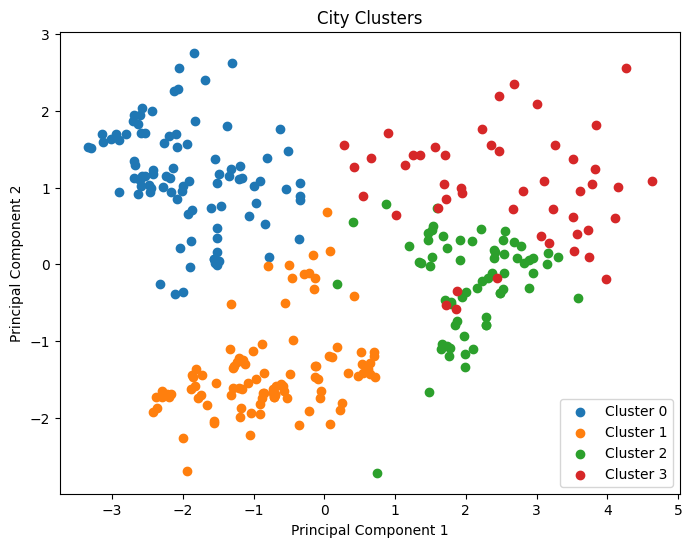

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for c in sorted(pdf.cluster.unique()):
    d = pdf[pdf.cluster==c]
    plt.scatter(d.PC1,d.PC2,label=f"Cluster {c}")

plt.legend()

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("City Clusters")

plt.show()

In [0]:
cluster_profile.toPandas().set_index("cluster")

,num_cities,avg_temp,avg_rainfall,avg_humidity,avg_cloud,avg_wind,avg_temp_range,avg_extreme_days
cluster,,,,,,,,
0,93,30.726372,946.108602,53.408175,19.156102,9.494753,0.0,16791.623656
1,97,24.835846,3207.680808,68.136840,25.848187,8.139626,0.0,14011.909091
2,66,28.390635,12080.306061,74.944604,54.279758,10.765639,0.0,21719.348485
3,37,27.698558,6445.025000,71.787686,47.794673,14.079899,0.0,29419.083333


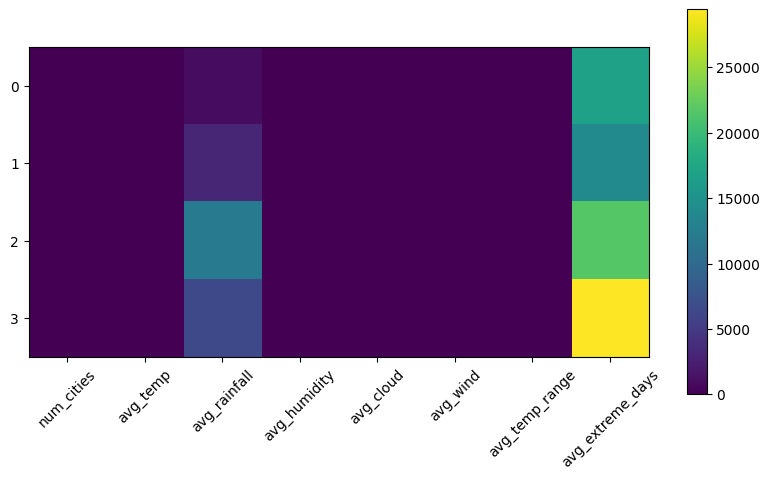

In [0]:
import matplotlib.pyplot as plt

heat = cluster_profile.toPandas()

heat = heat.set_index("cluster")

plt.figure(figsize=(10,5))

plt.imshow(heat,cmap="viridis")

plt.colorbar()

plt.xticks(range(len(heat.columns)),heat.columns,rotation=45)

plt.yticks(range(len(heat.index)),heat.index)

plt.show()

In [0]:
display(cluster_profile)

cluster,num_cities,avg_temp,avg_rainfall,avg_humidity,avg_cloud,avg_wind,avg_temp_range,avg_extreme_days
0,93,30.726372413339483,946.1086021505376,53.40817536663622,19.156102221882843,9.494752636621289,0.0,16791.62365591398
1,97,24.835846103911734,3207.680808080812,68.13683968432876,25.848187021367984,8.139625525371553,0.0,14011.90909090909
2,66,28.390635089602487,12080.306060606074,74.94460370533777,54.279758392400446,10.765638792860972,0.0,21719.348484848484
3,37,27.69855810043379,6445.025000000026,71.78768646266452,47.794673342952684,14.079899064528105,0.0,29419.083333333332


In [0]:
from pyspark.sql.functions import min,max

cols = [
    "avg_temp",
    "season_rain",
    "humidity",
    "weather_stability"
]

for c in cols:

    mn = clustered_df.select(min(c)).first()[0]

    mx = clustered_df.select(max(c)).first()[0]

    clustered_df = clustered_df.withColumn(
        c+"_norm",
        (col(c)-mn)/(mx-mn)
    )

In [0]:
clustered_df = clustered_df.withColumn(

    "agri_score",

    0.35*col("season_rain_norm")+

    0.30*col("humidity_norm")+

    0.20*col("weather_stability_index_norm")+

    0.15*col("avg_temp_norm")

)
clustered_df